In [15]:
%matplotlib widget

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [17]:
seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/PSF/Real_seeing_FIRST_1.txt")
sigmas = seeing / 2.35

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     363   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


Text(0.5, 1.0, 'H$\\alpha$')

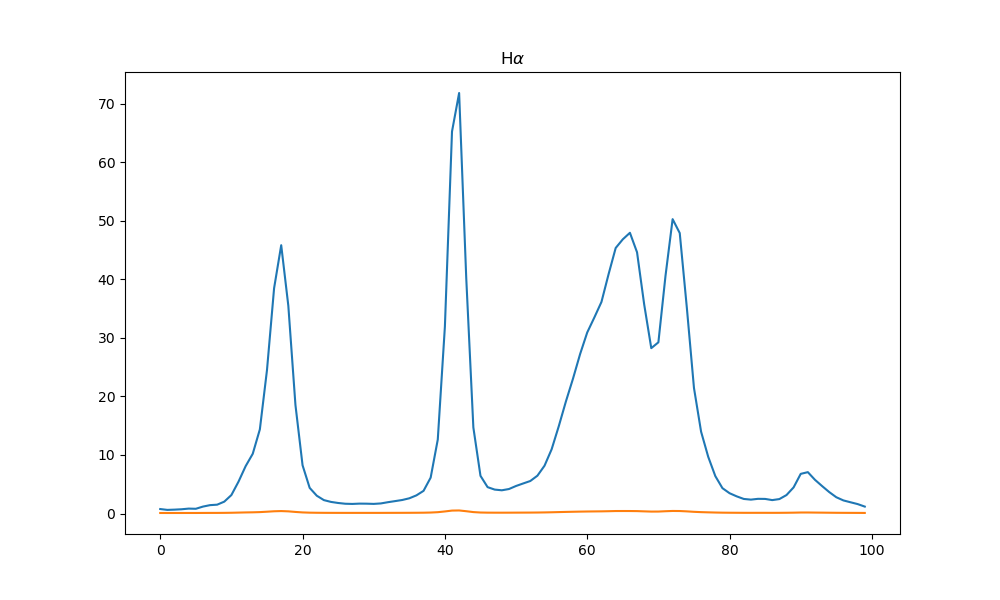

In [18]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/FIRST-J110949.3+124614_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

image_cut = image[49:149, 0:1890]
image_error_cut = image_error[49:149, 0:1890]
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

z = 0.04263
l_HA = 6563 * (1+z)

mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [19]:
n_component = 6

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, theta):
    # theta è un array 1D o DataFrame
    if isinstance(theta, np.ndarray):
        params = theta
    else:
        params = theta.values.flatten()
    
    x_hr = np.linspace(min(x), max(x), 4000)
    
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16]) +
        sersic_1d(x_hr, *params[16:20]) +
        sersic_1d(x_hr, *params[20:24])
    )
    
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def LogLikelihood(theta, x, sigma_y, y):
    model_values = model_convolved(x, sigmas[0], theta)
    return -0.5 * np.sum((y - model_values)**2 / sigma_y**2)
    
def Logprior(theta):
    # Riorganizza in shape (6, 4) per avere 6 componenti × [I, r, n, x0]
    params_array = theta.reshape(n_component, 4)
    
    I = params_array[:, 0]
    r = params_array[:, 1]
    n = params_array[:, 2]
    x0 = params_array[:, 3]
    
    if (np.all((Imin <= I) & (I <= Imax)) and 
        np.all((rmin <= r) & (r <= rmax)) and 
        np.all((nmin <= n) & (n <= nmax)) and 
        np.all((x0min <= x0) & (x0 <= x0max))):
        return 0.0
    else:
        return -np.inf
                  
def LogPosterior(theta, x, sigma_y, y):
    lp = Logprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + LogLikelihood(theta, x, sigma_y, y)

In [20]:
params = pd.read_csv("Halpha_fit.csv", index_col=0)
errors = pd.read_csv("Halpha_fit_errors.csv", index_col=0)
I = params.iloc[0].to_numpy()
r = params.iloc[1].to_numpy()
n = params.iloc[2].to_numpy()
x0 = params.iloc[3].to_numpy()
theta_initial = np.column_stack([I, r, n, x0]).flatten()

In [26]:
I_err = errors.iloc[0].to_numpy()
r_err = errors.iloc[1].to_numpy()
n_err = errors.iloc[2].to_numpy()
x0_err = errors.iloc[3].to_numpy()

Imin, Imax = np.zeros(len(I)), np.zeros(len(I))
rmin, rmax = np.zeros(len(I)), np.zeros(len(I))
nmin, nmax = np.zeros(len(I)), np.zeros(len(I))
x0min, x0max = np.zeros(len(I)), np.zeros(len(I))

Imin = np.maximum(0.1, I - I_err)
Imax = I + I_err
Imax[0] = 10
Imax[3] = 30
Imax[4] = 10

rmin = np.maximum(0.1, r - r_err)
rmax = r + r_err
rmin[0] = 2
rmax[1] = 20
rmin[2] = 4
rmax[5] = 25

nmin = np.maximum(0.5, n - n_err)
nmax = n + n_err
nmin[0] = 0

x0min = x0 - x0_err
x0max = x0 +x0_err

#Compute the loglike e logpost
loglike = LogLikelihood(theta_initial, x_axes, real_errors_HA, radial_profile_HA)
logpost = LogPosterior(theta_initial, x_axes, real_errors_HA, radial_profile_HA)
print(f"Log-likelihood iniziale: {loglike}")
print(f"Log-posterior iniziale: {logpost}")

Log-likelihood iniziale: -105.35967280430332
Log-posterior iniziale: -105.35967280430332


In [27]:
nmin

array([0.    , 0.5   , 0.6895, 0.5   , 1.2387, 0.6466])

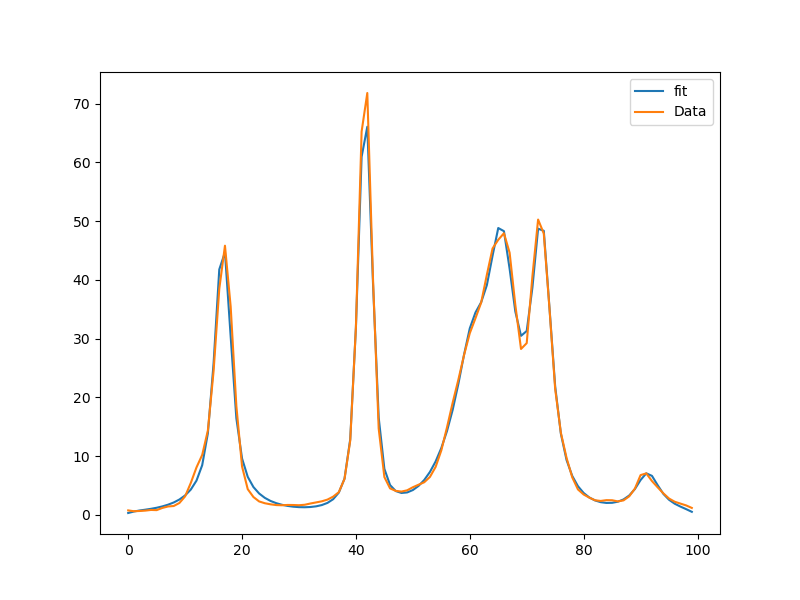

In [28]:
plt.figure(figsize = (8, 6))
x_axes = np.arange(0, 100, 1)
best_model = model_convolved(x_axes, sigmas[4], theta_initial)
plt.plot(x_axes, best_model, label = 'fit')
plt.plot(x_axes, radial_profile_HA, label = 'Data')
plt.legend()

In [29]:
#MCMC with emcee
params_init = theta_initial 

ndim = 24  
nwalkers = 50
nsteps = 100000

# Inizializza i walkers attorno ai valori iniziali
errors_flat = errors.values.flatten()
starting_guesses = params_init + 1e-4 * np.random.randn(nwalkers, ndim)

# Crea il sampler
backend = emcee.backends.HDFBackend("MCMC_params.h5")
backend.reset(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior, 
                                args=[x_axes, real_errors_HA, radial_profile_HA],\
                                        moves=[(emcee.moves.DEMove(), 0.7), (emcee.moves.DESnookerMove(), 0.3)], threads = -1, backend=backend)
print("Inizio MCMC...")
sampler.run_mcmc(starting_guesses, nsteps, progress=True, store=True)
print("MCMC completato!")

Inizio MCMC...


100%|████████████████████████████████████████████████████████████████████████| 100000/100000 [2:38:23<00:00, 10.52it/s]

MCMC completato!


In [ ]:
# Leggi il backend esistente
params_init = params.values.flatten()  

ndim = len(params_init)  
nwalkers = 50 
nsteps = 1000000
steps_da_fare = nsteps - backend.iteration

# Inizializza i walkers attorno ai valori iniziali
errors_flat = errors.values.flatten()
starting_guesses = params_init + 0.01 * errors_flat * np.random.randn(nwalkers, ndim)

backend = emcee.backends.HDFBackend("MCMC_params.h5")

# Ricrea il sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior, 
                                args=[x_axes, real_errors_HA, radial_profile_HA],\
                                        moves=[(emcee.moves.DEMove(), 0.7), (emcee.moves.DESnookerMove(), 0.3)], threads = -1, backend=backend)

# Riprendi dall'ultima posizione salvata
if backend.iteration == 0:
    print("Nuovo sampling...")
    initial_state = starting_guesses
else:
    print(f"Ripresa dal passo {backend.iteration}/{nsteps}...")
    last_sample = sampler.get_last_sample()
    
    # Controlla se i walkers sono troppo vicini
    coords = last_sample.coords
    
    # Aggiungi un piccolo rumore per ripristinare l'indipendenza
    noise_scale = 1e-6  # Inizia con un valore piccolo
    coords_perturbed = coords + noise_scale * np.random.randn(*coords.shape)
    
    # Crea un nuovo State con le coordinate perturbate
    from emcee.state import State
    initial_state = State(coords_perturbed, log_prob=last_sample.log_prob,
                          blobs=last_sample.blobs, random_state=last_sample.random_state)

# Continua il sampling
sampler.run_mcmc(initial_state, steps_da_fare, progress=True)

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

In [ ]:
from emcee import autocorr

samples_burn  = sampler.get_chain(discard=burn, flat=False)

fig, axes = plt.subplots(24, figsize=(10, 2.5*ndim), sharex=True)

for i in range(ndim):
    #ACF media su tutti i walker
    acf = np.mean([autocorr.function_1d(samples_burn[:, j, i]) 
                   for j in range(nwalkers)], axis=0)
    
    axes[i].plot(acf, 'royalblue', linewidth=2)
    axes[i].axhline(0, color='k', linestyle='--', alpha=0.5)
   # axes[i].axhline(1/np.e, color='crimson', linestyle='--', label='1/e')
    axes[i].set_ylabel(labels[i], fontsize=11)
    axes[i].grid(alpha=0.3)
    #axes[i].legend(fontsize=9)

axes[-1].set_xlabel('Lag', fontsize=12)
plt.tight_layout()
plt.savefig('ACF.png', dpi=150, bbox_inches='tight')